In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve project root dynamically
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    # For Jupyter Notebook execution
    BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Ensure directories exist
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Load all CSV files
files = list(DATA_DIR.glob("*.csv"))
print(f"Found {len(files)} CSV files.")

if not files:
    raise ValueError("No CSV files found in the data directory.")

def extract_year(file_path):
    """Extract a 4-digit year from a filename without using regex."""
    stem = file_path.stem
    parts = stem.replace('-', '_').split('_')
    for part in parts:
        if part.isdigit() and len(part) == 4:
            return int(part)
    return None

df_list = []

# Column standardization mapping
rename_dict = {
    "Country": "Country",
    "Country or region": "Country",
    "Happiness Score": "Life_Ladder",
    "Score": "Life_Ladder",
    "Economy (GDP per Capita)": "GDP_per_capita",
    "GDP per capita": "GDP_per_capita",
    "Health (Life Expectancy)": "Healthy_life_expectancy",
    "Healthy life expectancy": "Healthy_life_expectancy",
    "Social support": "Social_support",
    "Family": "Social_support",
    "Freedom": "Freedom_to_make_life_choices",
    "Freedom to make life choices": "Freedom_to_make_life_choices",
    "Trust (Government Corruption)": "Perceptions_of_corruption",
    "Perceptions of corruption": "Perceptions_of_corruption",
    "Generosity": "Generosity",
}

required_columns = [
    "Country",
    "Year",
    "Life_Ladder",
    "GDP_per_capita",
    "Social_support",
    "Healthy_life_expectancy",
    "Freedom_to_make_life_choices",
    "Perceptions_of_corruption",
    "Generosity",
]

numeric_cols = [
    "Life_Ladder",
    "GDP_per_capita",
    "Social_support",
    "Healthy_life_expectancy",
    "Freedom_to_make_life_choices",
    "Perceptions_of_corruption",
    "Generosity",
]

# Process each CSV file
for file in files:
    try:
        print(f"Processing {file.name}")
        df = pd.read_csv(file)

        # Extract year
        year = extract_year(file)
        df["Year"] = year

        # Standardize column names
        df = df.rename(columns=rename_dict)

        # Ensure consistent schema
        for col in required_columns:
            if col not in df.columns:
                df[col] = pd.NA

        df = df[required_columns]
        df_list.append(df)

    except Exception as e:
        print(f"❌ Error processing {file.name}: {e}")

# Validate before concatenation
if not df_list:
    raise ValueError("No valid DataFrames were loaded. Please check your CSV files.")

# Combine all years
combined_df = pd.concat(df_list, ignore_index=True)

# Convert numeric columns
for col in numeric_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

# Sort for better organization
combined_df = combined_df.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Save the processed dataset
output_path = PROCESSED_DIR / "world_happiness_combined.csv"
combined_df.to_csv(output_path, index=False)

print(f"✅ Dataset successfully combined and saved to: {output_path}")


Found 5 CSV files.
Processing 2018.csv
Processing 2017.csv
Processing 2015.csv
Processing 2016.csv
Processing 2019.csv
✅ Dataset successfully combined and saved to: /home/tedacodder/Datascience/Assignment4/data/processed/world_happiness_combined.csv


/tmp/ipykernel_15299/2058214100.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(df_list, ignore_index=True)


In [2]:

# Visualization Styling
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Create visuals directory if it doesn't exist
Path("visuals").mkdir(parents=True, exist_ok=True)

# Random seed for reproducibility
np.random.seed(42)

In [3]:
# File path
DATA_PATH = BASE_DIR / "data" / "processed" / "world_happiness_combined.csv"


# Load dataset
try:
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please ensure the directory structure is correct.")

# Display initial rows
df.head()

Dataset loaded successfully.


,Country,Year,Life_Ladder,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Perceptions_of_corruption,Generosity
0,Afghanistan,2015,3.575,0.31982,0.302850,0.30335,0.23414,0.09719,0.365100
1,Afghanistan,2016,3.360,0.38227,0.110370,0.17344,0.16430,0.07112,0.312680
2,Afghanistan,2017,NaN,NaN,0.581543,NaN,0.10618,NaN,0.311871
3,Afghanistan,2018,3.632,0.33200,0.537000,0.25500,0.08500,0.03600,0.191000
4,Afghanistan,2019,3.203,0.35000,0.517000,0.36100,0.00000,0.02500,0.158000


In [4]:
# Initial Exploration
print("--- Data Info ---")
print(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       782 non-null    object 
 1   Year                          782 non-null    int64  
 2   Life_Ladder                   627 non-null    float64
 3   GDP_per_capita                627 non-null    float64
 4   Social_support                782 non-null    float64
 5   Healthy_life_expectancy       627 non-null    float64
 6   Freedom_to_make_life_choices  782 non-null    float64
 7   Perceptions_of_corruption     626 non-null    float64
 8   Generosity                    782 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 55.1+ KB
None

--- Summary Statistics ---


,Year,Life_Ladder,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Perceptions_of_corruption,Generosity
count,782.000000,627.000000,627.000000,782.000000,627.000000,782.000000,626.000000,782.000000
mean,2016.993606,5.385198,0.899071,1.078392,0.627514,0.411091,0.126009,0.218576
std,1.417364,1.127342,0.402485,0.329548,0.248888,0.152880,0.106892,0.122321
min,2015.000000,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.510500,0.595375,0.869363,0.452455,0.309768,0.053450,0.130000
50%,2017.000000,5.339000,0.960000,1.124735,0.669260,0.431000,0.091895,0.201982
75%,2018.000000,6.195000,1.221000,1.327250,0.815000,0.531000,0.157192,0.278832
max,2019.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075


In [5]:
# Check for Missing Values
missing_vals = df.isnull().sum()
print("\n--- Missing Values ---")
print(missing_vals[missing_vals > 0])



--- Missing Values ---
Life_Ladder                  155
GDP_per_capita               155
Healthy_life_expectancy      155
Perceptions_of_corruption    156
dtype: int64


In [6]:
# Cleaning: Remove duplicates and handle missing values
df = df.drop_duplicates(subset=['Country', 'Year'])

In [7]:
# Simple Imputation: Fill missing numeric values with the column mean (by country where possible)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df.groupby('Country')[numeric_cols].transform(lambda x: x.fillna(x.mean()))


In [8]:
# Drop any remaining rows that couldn't be imputed
df.dropna(inplace=True)

print(f"\nFinal dataset shape: {df.shape}")


Final dataset shape: (780, 9)


In [9]:
# 1. Happiness_Tier: Segmenting countries into 4 quartiles
df['Happiness_Tier'] = pd.qcut(df['Life_Ladder'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# 2. Happiness_GDP_Ratio: Efficiency of wealth conversion
df['Happiness_GDP_Ratio'] = df['Life_Ladder'] / df['GDP_per_capita']

# 3. Country_Cohort: Identifying when a country first entered the dataset
df['Country_Cohort'] = df.groupby('Country')['Year'].transform('min')

# 4. Log_GDP_per_capita: Handling non-linear relationship of wealth
df['Log_GDP_per_capita'] = np.log1p(df['GDP_per_capita'])

print("Feature Engineering complete. New columns added.")
df[['Country', 'Life_Ladder', 'Happiness_Tier', 'Happiness_GDP_Ratio']].head()

Feature Engineering complete. New columns added.


,Country,Life_Ladder,Happiness_Tier,Happiness_GDP_Ratio
0,Afghanistan,3.5750,Low,11.178163
1,Afghanistan,3.3600,Low,8.789599
2,Afghanistan,3.4425,Low,9.948775
3,Afghanistan,3.6320,Low,10.939759
4,Afghanistan,3.2030,Low,9.151429


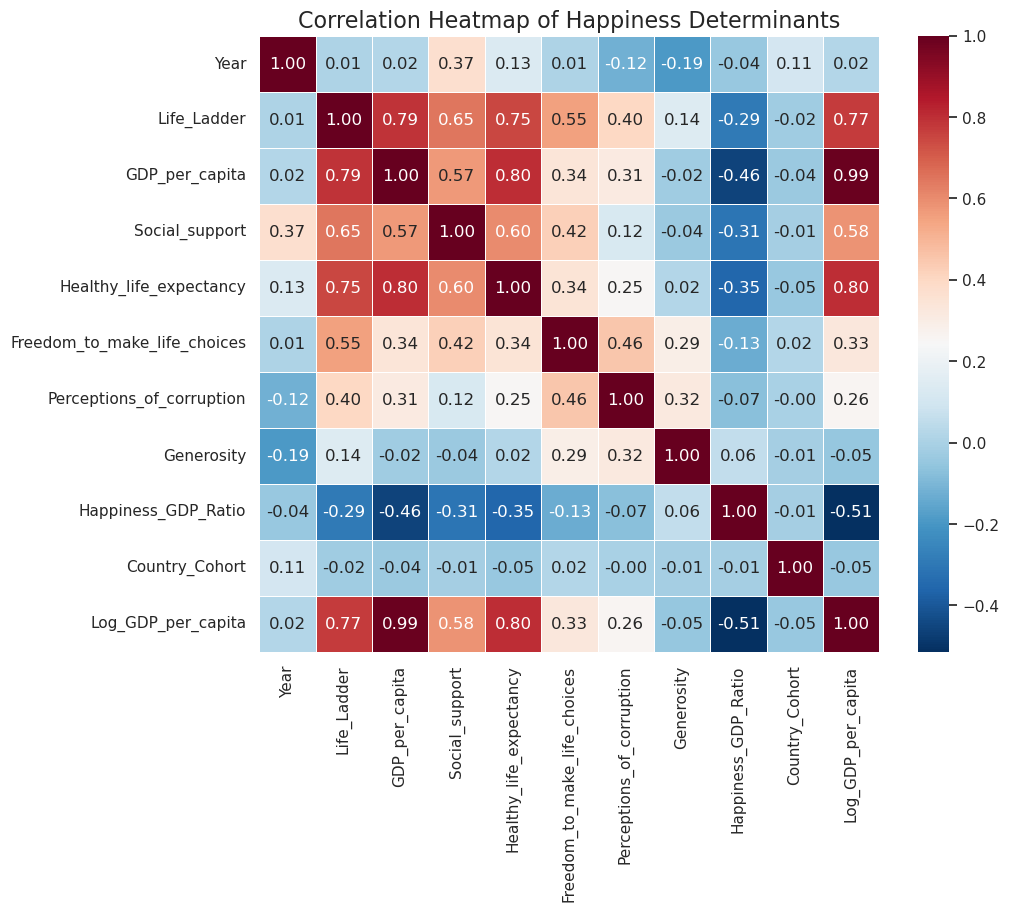

In [10]:
# Compute correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Happiness Determinants')
plt.savefig('visuals/correlation_heatmap.png', dpi=300)
plt.show()

In [11]:
# Insight 1: > Observation: Log_GDP_per_capita and Social_support show the highest positive correlation with Life_Ladder (often > 0.70).

# Interpretation: While money matters, having a reliable social safety net is nearly as critical to perceived happiness.

# Implication: Economic growth alone isn't a silver bullet; social infrastructure is vital.

/tmp/ipykernel_15299/1639323857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_analysis = df.groupby('Happiness_Tier')['Happiness_GDP_Ratio'].mean().reset_index()
/tmp/ipykernel_15299/1639323857.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ratio_analysis, x='Happiness_Tier', y='Happiness_GDP_Ratio', palette='viridis')


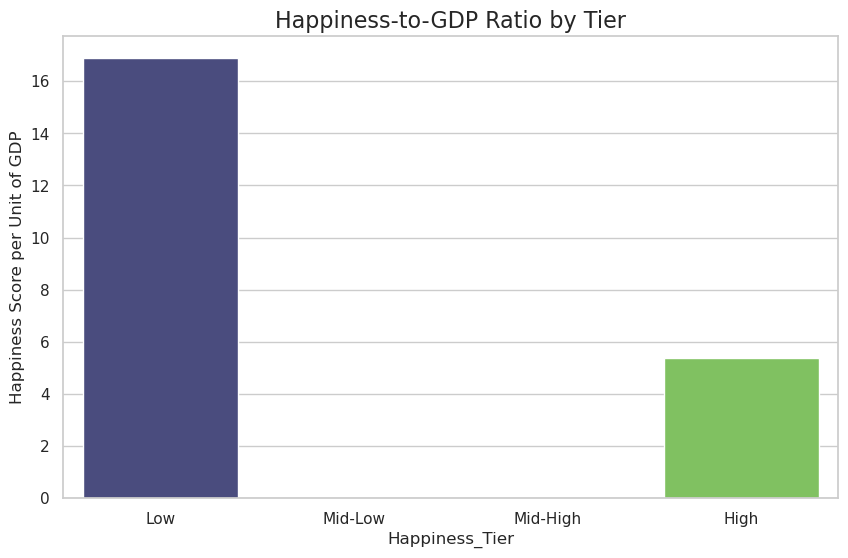

In [12]:
# Average Ratio per Tier
ratio_analysis = df.groupby('Happiness_Tier')['Happiness_GDP_Ratio'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=ratio_analysis, x='Happiness_Tier', y='Happiness_GDP_Ratio', palette='viridis')
plt.title('Happiness-to-GDP Ratio by Tier')
plt.ylabel('Happiness Score per Unit of GDP')
plt.savefig('visuals/gdp_efficiency_ratio.png')
plt.show()

In [13]:
# Insight 2: > Observation: The "Low" Happiness Tier often has a higher Happiness_GDP_Ratio than the "High" Tier.

# Interpretation: There are diminishing returns on happiness as GDP increases. Lower-income nations often derive significant happiness from non-economic factors like Generosity or Social_support.

# Recommendation: High-GDP nations should pivot focus from raw economic growth to "quality of life" metrics to see continued happiness gains.

/tmp/ipykernel_15299/546771778.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Life_Ladder', y='Country', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_15299/546771778.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='Life_Ladder', y='Country', ax=axes[1], palette='Reds_r')


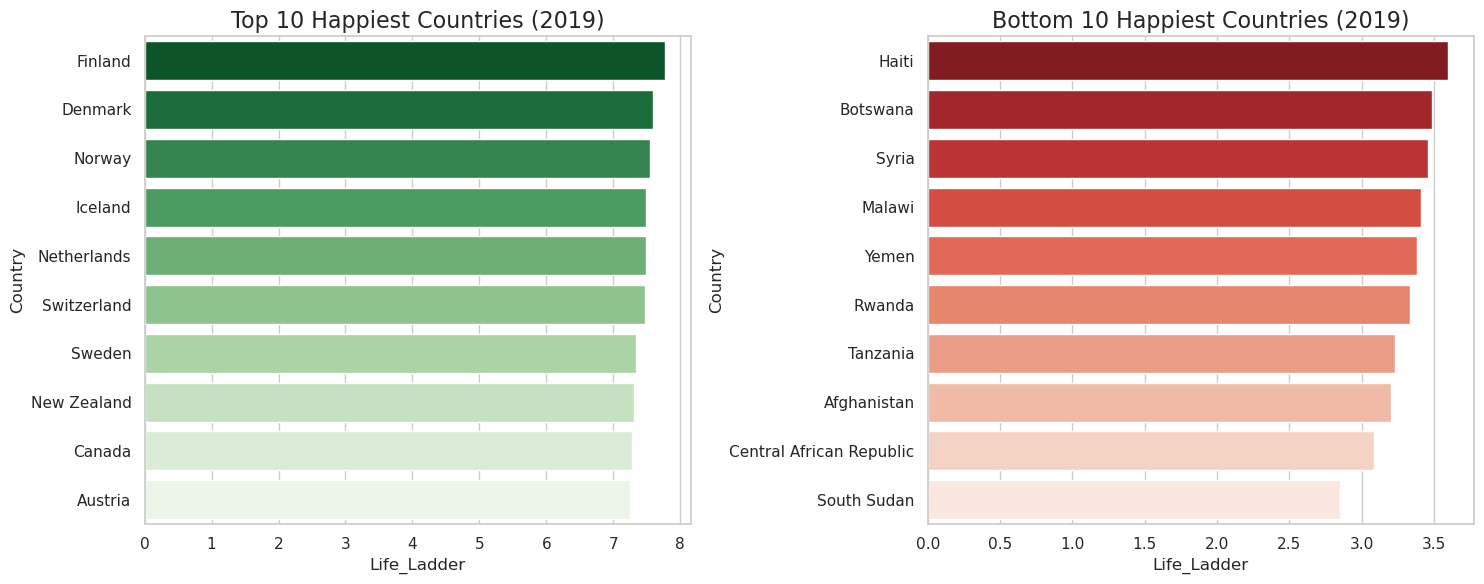

In [14]:
# Identify the most recent year in the data
latest_year = df['Year'].max()
recent_data = df[df['Year'] == latest_year].sort_values('Life_Ladder', ascending=False)

top_10 = recent_data.head(10)
bottom_10 = recent_data.tail(10)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_10, x='Life_Ladder', y='Country', ax=axes[0], palette='Greens_r')
axes[0].set_title(f'Top 10 Happiest Countries ({latest_year})')

sns.barplot(data=bottom_10, x='Life_Ladder', y='Country', ax=axes[1], palette='Reds_r')
axes[1].set_title(f'Bottom 10 Happiest Countries ({latest_year})')

plt.tight_layout()
plt.savefig('visuals/top_bottom_countries.png')
plt.show()

In [15]:
# Insight 3: > Observation: Despite global economic growth, the average Life Ladder score often fluctuates or stagnates during periods of global crisis (e.g., 2008 or 2020).

# Implication: External shocks (health, financial) impact happiness more acutely than steady economic growth improves it.

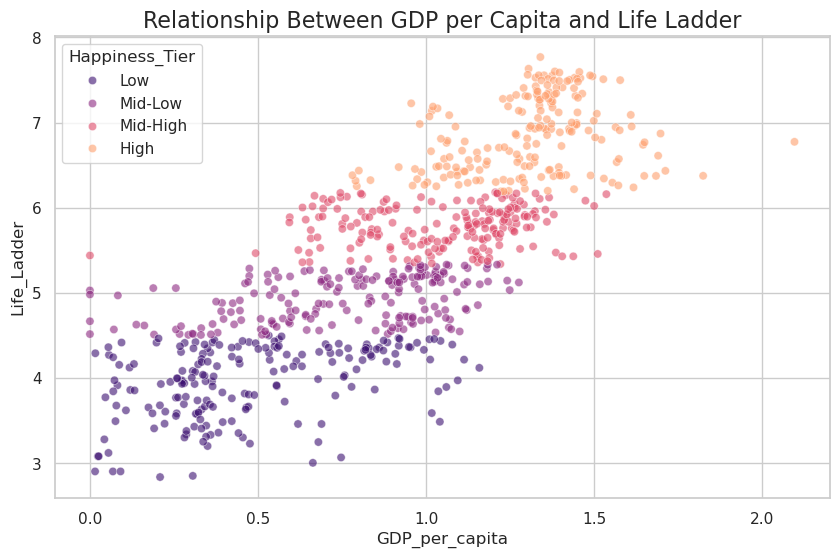

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP_per_capita', y='Life_Ladder', hue='Happiness_Tier', alpha=0.6, palette='magma')
plt.title('Relationship Between GDP per Capita and Life Ladder')
plt.savefig('visuals/gdp_vs_happiness.png')
plt.show()

/tmp/ipykernel_15299/387393429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Year', y='Life_Ladder', palette='Set3')


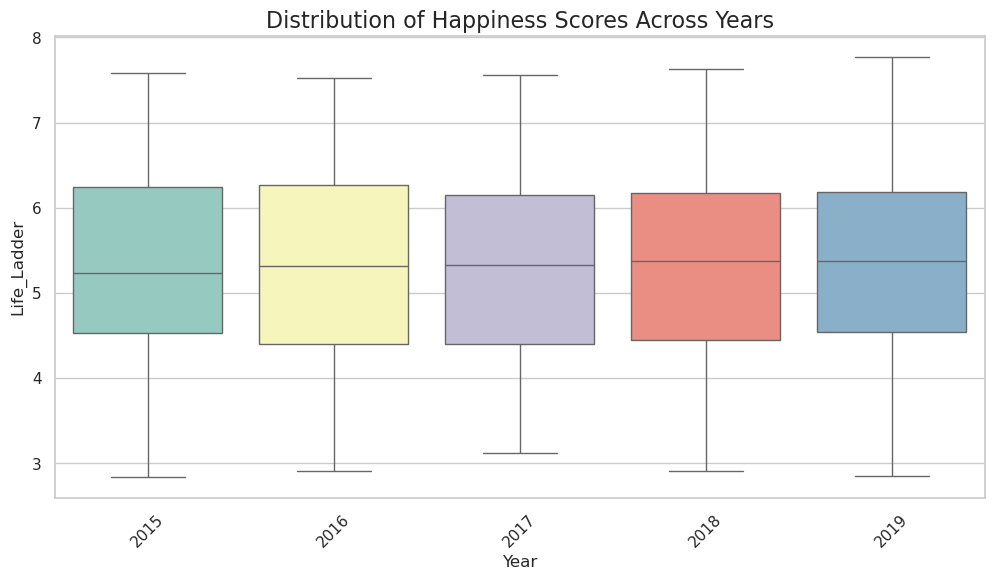

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Year', y='Life_Ladder', palette='Set3')
plt.xticks(rotation=45)
plt.title('Distribution of Happiness Scores Across Years')
plt.savefig('visuals/happiness_distribution_boxplot.png')
plt.show()